# CS 8267 - Fall 2023 - Final Project
## Text Summarization using Seq2Seq based model
### By Caleb Greski, Faruk Muritala, Promi Roy, and Venkata Abhiram Chitty

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U nltk # To Upgrade NLTK to >3.8 for METEOR score

In [3]:
import nltk

print('The nltk version is {}.'.format(nltk.__version__)) # Verify version >3.8.1

The nltk version is 3.8.1.


In [4]:
import numpy as np
import pandas as pd

In [5]:
import pandas as pd

# Assuming the file is named 'your_file.csv'
file_path = 'test.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path, encoding='iso-8859-1')

# Display the first few rows of the DataFrame
print(df.head())


                                         id  \
0  92c514c913c0bdfe25341af9fd72b29db544099b   
1  2003841c7dc0e7c5b1a248f9cd536d727f27a45a   
2  91b7d2311527f5c2b63a65ca98d21d9c92485149   
3  caabf9cbdf96eb1410295a673e953d304391bfbb   
4  3da746a7d9afcaa659088c8366ef6347fe6b53ea   

                                             article  \
0  Ever noticed how plane seats appear to be gett...   
1  A drunk teenage boy had to be rescued by secur...   
2  Dougie Freedman is on the verge of agreeing a ...   
3  Liverpool target Neto is also wanted by PSG an...   
4  Bruce Jenner will break his silence in a two-h...   

                                          highlights  
0  Experts question if  packed out planes are put...  
1  Drunk teenage boy climbed into lion enclosure ...  
2  Nottingham Forest are close to extending Dougi...  
3  Fiorentina goalkeeper Neto has been linked wit...  
4  Tell-all interview with the reality TV star, 6...  


In [6]:
import pandas as pd

# Assuming the DataFrame is named 'df'
# Use the 'article' column as 'raw'
raw = df['article']

# Use the 'highlights' column as 'summary'
summary = df['highlights']


In [7]:
import pandas as pd

# Assuming the DataFrame is named 'df'
# Create a new DataFrame
pre_data = pd.DataFrame()

# Use the 'article' column as 'text'
pre_data['text'] = df['article']

# Use the 'highlights' column as 'summary'
pre_data['summary'] = df['highlights']

# Display the first few rows of the resulting DataFrame
print(pre_data.head())


                                                text  \
0  Ever noticed how plane seats appear to be gett...   
1  A drunk teenage boy had to be rescued by secur...   
2  Dougie Freedman is on the verge of agreeing a ...   
3  Liverpool target Neto is also wanted by PSG an...   
4  Bruce Jenner will break his silence in a two-h...   

                                             summary  
0  Experts question if  packed out planes are put...  
1  Drunk teenage boy climbed into lion enclosure ...  
2  Nottingham Forest are close to extending Dougi...  
3  Fiorentina goalkeeper Neto has been linked wit...  
4  Tell-all interview with the reality TV star, 6...  


In [8]:
pre_data.head(2)

,text,summary
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...


**Seq2Seq LSTM Modelling**

In [9]:
pre_data['text'][:10]

0    Ever noticed how plane seats appear to be gett...
1    A drunk teenage boy had to be rescued by secur...
2    Dougie Freedman is on the verge of agreeing a ...
3    Liverpool target Neto is also wanted by PSG an...
4    Bruce Jenner will break his silence in a two-h...
5    This is the moment that a crew of firefighters...
6    The amount of time people spend listening to B...
7    (CNN)So, you'd like a "Full House" reunion and...
8    At 11:20pm, former world champion Ken Doherty ...
9    A gang of six men have been jailed for a total...
Name: text, dtype: object

> **Perform Data Cleansing**

In [10]:
import re

#Removes non-alphabetic characters:
def text_strip(column):
    for row in column:

        row=re.sub("(\\t)", ' ', str(row)).lower() #delete escape charecters
        row=re.sub("(\\r)", ' ', str(row)).lower()
        row=re.sub("(\\n)", ' ', str(row)).lower()

        row=re.sub("(__+)", ' ', str(row)).lower()   #delete _ if more than one time repeatedly
        row=re.sub("(--+)", ' ', str(row)).lower()   #delete - if more than one time repeatedly
        row=re.sub("(~~+)", ' ', str(row)).lower()   #delete ~ if more than one time repeatedly
        row=re.sub("(\+\++)", ' ', str(row)).lower()   #delete + if more than one time repeatedly
        row=re.sub("(\.\.+)", ' ', str(row)).lower()   #delete . if more than one time repeatedly

        row=re.sub(r"[<>()|&©ø\[\]\'\",;?~*!]", ' ', str(row)).lower() #delete <>()|&©ø"',;?~*!

        row=re.sub("(mailto:)", ' ', str(row)).lower() #delete mailto:
        row=re.sub(r"(\\x9\d)", ' ', str(row)).lower() #delete \x9* in text
        row=re.sub("([iI][nN][cC]\d+)", 'INC_NUM', str(row)).lower() #replace INC nums to INC_NUM
        row=re.sub("([cC][mM]\d+)|([cC][hH][gG]\d+)", 'CM_NUM', str(row)).lower() #replace CM# and CHG# to CM_NUM


        row=re.sub("(\.\s+)", ' ', str(row)).lower() #delete full stop at end of words(not between)
        row=re.sub("(\-\s+)", ' ', str(row)).lower() #delete - at end of words(not between)
        row=re.sub("(\:\s+)", ' ', str(row)).lower() #delete : at end of words(not between)

        row=re.sub("(\s+.\s+)", ' ', str(row)).lower() #delete any single charecters hanging between 2 spaces

        # Change url http://www.youtube.com/watch/43865346kcre8375 ====> www.youtube.com
        try:
            url = re.search(r'((https*:\/*)([^\/\s]+))(.[^\s]+)', str(row))
            repl_url = url.group(3)
            row = re.sub(r'((https*:\/*)([^\/\s]+))(.[^\s]+)',repl_url, str(row))
        except:
            pass #there might be emails with no url in them



        row = re.sub("(\s+)",' ',str(row)).lower() #delete multiple spaces

        #Should always be last
        row=re.sub("(\s+.\s+)", ' ', str(row)).lower() #delete any single charecters hanging between 2 spaces



        yield row




###Save the clean data to files  

In [11]:
text_count = []
summary_count = []

In [12]:
for sent in pre_data['text']:
    text_count.append(len(sent.split()))
for sent in pre_data['summary']:
    summary_count.append(len(sent.split()))

In [13]:
graph_df= pd.DataFrame()
graph_df['text']=text_count
graph_df['summary']=summary_count

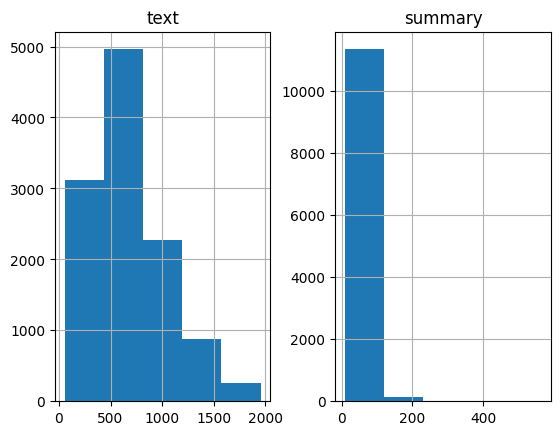

In [14]:
import matplotlib.pyplot as plt

graph_df.hist(bins = 5)
plt.show()

In [71]:
#Check how much % of summary have 0-85 words
count=0
for i in pre_data['summary']:
    if(len(i.split())<=85):
        count=count+1
print(count/len(pre_data['summary']))

0.9188859878154917


In [79]:
#Check how much % of text have 0-1200 words
count=0
for i in pre_data['text']:
    if(len(i.split())<=1200):
        count=count+1
print(count/len(pre_data['text']))

0.9030461270670148


In [80]:
#Model to summarize the text between 0-15 words for Summary and 0-100 words for Text

max_text_len=1200
max_summary_len=85

In [81]:
#Select the Summaries and Text between max len defined above

cleaned_text =np.array(pre_data['text'])
cleaned_summary=np.array(pre_data['summary'])

short_text=[]
short_summary=[]

for i in range(len(cleaned_text)):
    if(len(cleaned_summary[i].split())<=max_summary_len and len(cleaned_text[i].split())<=max_text_len):
        short_text.append(cleaned_text[i])
        short_summary.append(cleaned_summary[i])

post_pre_data=pd.DataFrame({'text':short_text,'summary':short_summary})

In [82]:
post_pre_data.head(2)

,text,summary
0,"Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putti...",Experts question if packed out planes are putting passengers at risk .\nU.S consumer advisory group says minimum space must be stipulated .\nSafety tests conducted on planes with more leg room th...
1,"A drunk teenage boy had to be rescued by security after jumping into a lions' enclosure at a zoo in western India. Rahul Kumar, 17, clambered over the enclosure fence at theÂ Kamla Nehru Zoologica...","Drunk teenage boy climbed into lion enclosure at zoo in west India .\nRahul Kumar, 17, ran towards animals shouting 'Today I kill a lion!'\nFortunately he fell into a moat before reaching lions an..."


In [83]:
#Add sostok and eostok at
post_pre_data['summary'] = post_pre_data['summary'].apply(lambda x : 'sostok '+ x + ' eostok')


In [84]:
post_pre_data.head(2)

,text,summary
0,"Ever noticed how plane seats appear to be getting smaller and smaller? With increasing numbers of people taking to the skies, some experts are questioning if having such packed out planes is putti...",sostok Experts question if packed out planes are putting passengers at risk .\nU.S consumer advisory group says minimum space must be stipulated .\nSafety tests conducted on planes with more leg ...
1,"A drunk teenage boy had to be rescued by security after jumping into a lions' enclosure at a zoo in western India. Rahul Kumar, 17, clambered over the enclosure fence at theÂ Kamla Nehru Zoologica...","sostok Drunk teenage boy climbed into lion enclosure at zoo in west India .\nRahul Kumar, 17, ran towards animals shouting 'Today I kill a lion!'\nFortunately he fell into a moat before reaching l..."


**SEQ2SEQ MODEL BUILDING **

Split the data to TRAIN and VALIDATION sets

In [85]:
from sklearn.model_selection import train_test_split
x_tr,x_val,y_tr,y_val=train_test_split(np.array(post_pre_data['text']),np.array(post_pre_data['summary']),test_size=0.1,random_state=0,shuffle=True)

In [86]:
#Lets tokenize the text to get the vocab count , you can use Spacy here also

from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

#prepare a tokenizer for reviews on training data
x_tknizer = Tokenizer()
x_tknizer.fit_on_texts(list(x_tr))

**RARE WORD ANALYSIS FOR X i.e 'text'**
* total_count gives the size of vocabulary (which means every unique words in the text)

* count gives me the no. of rare words whose count falls below threshold

* total_count - count gives me the top most common words

In [87]:
thresh=4

count=0
total_count=0
frequency=0
total_frequency=0

for key,value in x_tknizer.word_counts.items():
    total_count=total_count+1
    total_frequency=total_frequency+value
    if(value<thresh):
        count=count+1
        frequency=frequency+value

print("% of rare words in vocabulary:",(count/total_count)*100)
print("Total Coverage of rare words:",(frequency/total_frequency)*100)

% of rare words in vocabulary: 63.06290868094702
Total Coverage of rare words: 1.9805839077316794


In [88]:

#prepare a tokenizer for reviews on training data
x_tknizer = Tokenizer(num_words=total_count-count)
x_tknizer.fit_on_texts(list(x_tr))

#convert text sequences into integer sequences (i.e one-hot encodeing all the words)
x_tr_seq    =   x_tknizer.texts_to_sequences(x_tr)
x_val_seq   =   x_tknizer.texts_to_sequences(x_val)

#padding zero upto maximum length
x_tr    =   pad_sequences(x_tr_seq,  maxlen=max_text_len, padding='post')
x_val   =   pad_sequences(x_val_seq, maxlen=max_text_len, padding='post')

#size of vocabulary ( +1 for padding token)
x_voc   =  x_tknizer.num_words + 1

print("Size of vocabulary in X = {}".format(x_voc))

Size of vocabulary in X = 40955


**RARE WORD ANALYSIS FOR Y i.e 'summary'**
* total_count gives the size of vocabulary (which means every unique words in the text)

* count gives me the no. of rare words whose count falls below threshold

* total_count - count gives me the top most common words

In [89]:
#prepare a tokenizer for reviews on training data
y_tknizer = Tokenizer()
y_tknizer.fit_on_texts(list(y_tr))

In [90]:
thresh=6

count=0
total_count=0
frequency=0
total_frequency=0

for key,value in y_tknizer.word_counts.items():
    total_count=total_count+1
    total_frequency=total_frequency+value
    if(value<thresh):
        count=count+1
        frequency=frequency+value

print("% of rare words in vocabulary:",(count/total_count)*100)
print("Total Coverage of rare words:",(frequency/total_frequency)*100)

% of rare words in vocabulary: 80.57157043943616
Total Coverage of rare words: 11.424323007828614


In [91]:
#prepare a tokenizer for reviews on training data
y_tknizer = Tokenizer(num_words=total_count-count)
y_tknizer.fit_on_texts(list(y_tr))

#convert text sequences into integer sequences (i.e one hot encode the text in Y)
y_tr_seq    =   y_tknizer.texts_to_sequences(y_tr)
y_val_seq   =   y_tknizer.texts_to_sequences(y_val)

#padding zero upto maximum length
y_tr    =   pad_sequences(y_tr_seq, maxlen=max_summary_len, padding='post')
y_val   =   pad_sequences(y_val_seq, maxlen=max_summary_len, padding='post')

#size of vocabulary
y_voc  =   y_tknizer.num_words +1
print("Size of vocabulary in Y = {}".format(y_voc))

Size of vocabulary in Y = 7044


We will now delete "Summary" i.e Y (both train and val) which has only _START_ and _END_

In [92]:
ind=[]
for i in range(len(y_tr)):
    count=0
    for j in y_tr[i]:
        if j!=0:
            count=count+1
    if(count==2):
        ind.append(i)

y_tr=np.delete(y_tr,ind, axis=0)
x_tr=np.delete(x_tr,ind, axis=0)

In [93]:
ind=[]
for i in range(len(y_val)):
    count=0
    for j in y_val[i]:
        if j!=0:
            count=count+1
    if(count==2):
        ind.append(i)

y_val=np.delete(y_val,ind, axis=0)
x_val=np.delete(x_val,ind, axis=0)

In [94]:
from keras import backend as K
import gensim
from numpy import *
import numpy as np
import pandas as pd
import re
from bs4 import BeautifulSoup
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import warnings
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore")

K.clear_session()

latent_dim = 300
embedding_dim=200

# Encoder
encoder_inputs = Input(shape=(max_text_len,))

#embedding layer
enc_emb =  Embedding(x_voc, embedding_dim,trainable=True)(encoder_inputs)

#encoder lstm 1
encoder_lstm1 = LSTM(latent_dim,return_sequences=True,return_state=True,dropout=0.4,recurrent_dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

#encoder lstm 2
encoder_lstm2 = LSTM(latent_dim,return_sequences=True,return_state=True,dropout=0.4,recurrent_dropout=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

#encoder lstm 3
encoder_lstm3=LSTM(latent_dim, return_state=True, return_sequences=True,dropout=0.4,recurrent_dropout=0.4)
encoder_outputs, state_h, state_c= encoder_lstm3(encoder_output2)

# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = Input(shape=(None,))

#embedding layer
dec_emb_layer = Embedding(y_voc, embedding_dim,trainable=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True,dropout=0.4,recurrent_dropout=0.2)
decoder_outputs,decoder_fwd_state, decoder_back_state = decoder_lstm(dec_emb,initial_state=[state_h, state_c])

#dense layer - softmax
decoder_dense =  TimeDistributed(Dense(y_voc, activation='softmax'))
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1200)]               0         []                            
                                                                                                  
 embedding (Embedding)       (None, 1200, 200)            8191000   ['input_1[0][0]']             
                                                                                                  
 lstm (LSTM)                 [(None, 1200, 300),          601200    ['embedding[0][0]']           
                              (None, 300),                                                        
                              (None, 300)]                                                        
                                                                                              

In [95]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')


In [96]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1,patience=2)


In [97]:
y_tr[:,:-1].shape

(8711, 84)

In [98]:
import gc
gc.collect()

283

**Start fitting the model with the data**

In [ ]:
history=model.fit([x_tr,y_tr[:,:-1]], y_tr.reshape(y_tr.shape[0],y_tr.shape[1], 1)[:,1:] ,epochs=50,callbacks=[es],batch_size=32, validation_data=([x_val,y_val[:,:-1]], y_val.reshape(y_val.shape[0],y_val.shape[1], 1)[:,1:]))
#note batch_size should be a multiple of 8

Epoch 1/50
 16/273 [>.............................] - ETA: 1:23:32 - loss: 6.1956

###Save model weights

In [ ]:
model.save_weights('/content/drive/MyDrive/NN_ProjectData/model/fitted_model')

###Load model weights

In [ ]:
model = model.load_weights('/content/drive/MyDrive/NN_ProjectData/model/fitted_model')

**Plot model learning curve**

In [ ]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [ ]:
reverse_target_word_index=y_tknizer.index_word
reverse_source_word_index=x_tknizer.index_word
target_word_index=y_tknizer.word_index

In [ ]:
# Encoding our input seq for feature vector
encoder_model = Model(inputs=encoder_inputs,outputs=[encoder_outputs, state_h, state_c])

decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_hidden_state_input = Input(shape=(max_text_len,latent_dim))

dec_emb2= dec_emb_layer(decoder_inputs)

# initial states from the previous time step
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

# softmax for probability
decoder_outputs2 = decoder_dense(decoder_outputs2)

decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input,decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2])

In [ ]:
def decode_sequence(input_seq):
    # Encode the input as state vectors.
    e_out, e_h, e_c = encoder_model.predict(input_seq)

    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))

    # Populate the first word of target sequence with the start word.
    target_seq[0, 0] = target_word_index['sostok']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:

        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = reverse_target_word_index[sampled_token_index]

        if(sampled_token!='eostok'):
            decoded_sentence += ' '+sampled_token

        # Exit condition: either hit max length or find stop word.
        if (sampled_token == 'eostok'  or len(decoded_sentence.split()) >= (max_summary_len-1)):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update internal states
        e_h, e_c = h, c

    return decoded_sentence

In [ ]:
def sequence_to_summary(input_seq):
    newString=''
    for i in input_seq:
        if((i!=0 and i!=target_word_index['sostok']) and i!=target_word_index['eostok']):
            newString=newString+reverse_target_word_index[i]+' '
    return newString

def sequence_to_text(input_seq):
    newString=''
    for i in input_seq:
        if(i!=0):
            newString=newString+reverse_source_word_index[i]+' '
    return newString

###Predict and print summaries from model

In [ ]:
for i in range(0,10):
    print("Review:",sequence_to_text(x_tr[i]))
    print("Original summary:",(sequence_to_summary(y_tr[i])).replace('start', '').replace('end', ''))
    print("Predicted summary:",(decode_sequence(x_tr[i].reshape(1,max_text_len))).replace('start', '').replace('end', ''))
    print("\n")

#Calculating scores

###Function to calculate BLEU, GLEU and METEOR scores

In [ ]:
nltk.download('wordnet')

In [ ]:
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.gleu_score import sentence_gleu
from nltk.translate.meteor_score import meteor_score

def calculate_scores(N=100):
    bscore=0;gscore=0;mscore=0
    for i in range(N):
        ref=sequence_to_summary(y_tr[i])
        hypo=decode_sequence(x_tr[i].reshape(1,max_text_len))
        bscore+=sentence_bleu([ref],hypo)
        gscore+=sentence_gleu([ref],hypo)
        mscore+=meteor_score([ref],hypo)
    print("BLEU:%.4f GLEU:%.4f METEOR:%.4f"%(bscore/N,gscore/N,mscore/N))

###Calculating score metrics for first 100

In [ ]:
calculate_scores()